## Notebook14b

### Setup

Run all of the following before starting the notebook.

In [1]:
! wget -q -nc https://raw.githubusercontent.com/taylor-arnold/fds-py-nb/refs/heads/main/funs.py

In [2]:
import numpy as np
import polars as pl

from funs import *
from plotnine import *
from polars import col as c

import torch
import torch.nn as nn
import torch.optim as optim

theme_set(theme_minimal())
pl.Config(tbl_rows=25)

ub = "https://raw.githubusercontent.com/taylor-arnold/fds-py-nb/refs/heads/main/"

In [3]:
!mkdir -p models
!wget -q -nc -P models https://humanitiesdata.org/models/model_cnn_agnews.pt
!wget -q -nc -P models https://humanitiesdata.org/models/model_pre_agnews.pt
!wget -q -nc -P models https://humanitiesdata.org/models/word2vec.model

In [4]:
agnews = pl.read_parquet(ub + "data/agnews_pca.parquet")

### Part 1: Word Embedding

1. We will start by installing the gensim library, which is not one of the libraries available by default on Colab.

In [5]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.7 MB/s eta 0:00:00


2. Once the library is install, load the `Word2Vec` model.

In [6]:
from gensim.models import Word2Vec

3. As we did in the text with the IMDb data, we want to compute the tokens in the AG News dataset.

In [7]:
agnews = (
    agnews
    .with_columns(
        tokens = c.text.str.to_lowercase().str.extract_all(r"[a-z]+")
    )
)
agnews

id,label,text,index,e5,tokens
str,str,str,str,list[f64],list[str]
"""doc0001""","""Business""","""Wall St. Bears Claw Back Into …","""train""","[-0.036545, 0.005207, … -0.026625]","[""wall"", ""st"", … ""again""]"
"""doc0002""","""Business""","""Carlyle Looks Toward Commercia…","""train""","[-0.104543, 0.050969, … -0.042826]","[""carlyle"", ""looks"", … ""market""]"
"""doc0003""","""Business""","""Oil and Economy Cloud Stocks' …","""train""","[-0.083586, -0.041227, … 0.017097]","[""oil"", ""and"", … ""doldrums""]"
"""doc0004""","""Business""","""Iraq Halts Oil Exports from Ma…","""train""","[0.023902, -0.177082, … -0.028889]","[""iraq"", ""halts"", … ""saturday""]"
"""doc0005""","""Business""","""Oil prices soar to all-time re…","""train""","[-0.051798, -0.107815, … -0.009821]","[""oil"", ""prices"", … ""elections""]"
"""doc0006""","""Business""","""Stocks End Up, But Near Year L…","""train""","[-0.089434, 0.043536, … -0.002916]","[""stocks"", ""end"", … ""o""]"
"""doc0007""","""Business""","""Money Funds Fell in Latest Wee…","""train""","[-0.067089, -0.082679, … 0.010706]","[""money"", ""funds"", … ""thursday""]"
"""doc0008""","""Business""","""Fed minutes show dissent over …","""train""","[-0.080768, -0.046881, … -0.044812]","[""fed"", ""minutes"", … ""slump""]"
"""doc0009""","""Business""","""Safety Net (Forbes.com) Forbes…","""train""","[-0.07234, 0.048754, … -0.007753]","[""safety"", ""net"", … ""riley""]"


4. Next, we build the Word2Vec model. Here, we use the same settings as in the text except that we increase the minimum word count due to the increased size of the texts. The code here will only build the model if it has not already been run to save some time in future runs.

In [8]:
try:
    model = Word2Vec.load("models/word2vec.model")
except FileNotFoundError:
    model = Word2Vec(
        sentences=agnews["tokens"].to_list(),
        vector_size=100,
        window=2,
        min_count=25,
        sg=1,
        epochs=20
    )
    model.save("models/word2vec.model")

5. Check the length of the embedding. These are the number of words in the text.

In [9]:
len(model.wv)

11993

6. Now that we have the embedding, we will apply it to all of the texts.

In [10]:
embed = pl.DataFrame({
    "word": list(set(model.wv.key_to_index)),
    "embedding": [model.wv[w].tolist() for w in set(model.wv.key_to_index)],
})
embed

word,embedding
str,list[f64]
"""engine""","[-0.131437, 0.712665, … 1.140754]"
"""sluggish""","[-0.402898, 0.679181, … 0.394457]"
"""liberty""","[-0.01869, 0.066422, … 0.551533]"
"""breaks""","[-0.018302, 0.269552, … 0.025815]"
"""realize""","[-0.060521, 0.213662, … -0.553441]"
"""cautioned""","[0.062441, -0.395099, … -0.201564]"
"""dupont""","[0.060776, 0.010528, … 0.232294]"
"""uprising""","[-1.141641, 0.19737, … 0.966797]"
"""infections""","[-0.235095, -0.219381, … 0.181091]"


7. And finally, we can check how the embedding works by seeing what words are similar to one another. Start with my intial suggestion, but play around with different word choices.

In [32]:
model.wv.most_similar("liberty", topn=10)

[('walt', 0.48388513922691345),
 ('malone', 0.47470900416374207),
 ('murdoch', 0.4721270203590393),
 ('rupert', 0.4690019190311432),
 ('viacom', 0.4606230556964874),
 ('texans', 0.44263985753059387),
 ('arizona', 0.4424852430820465),
 ('espn', 0.4420897960662842),
 ('cnbc', 0.44207972288131714),
 ('raleigh', 0.43675532937049866)]

### Part 2: CNNs

8. Now let's create the training and testing data for our AG News corpus.

In [12]:
X, X_train, X_test, y, y_train, y_test, cn = DSTorch.load_text(
    df=agnews,
    model=model,
    tokens_expr=c.tokens,
    label_expr=c.label
)
embedding_dim = model.vector_size
embedding_matrix = torch.tensor(model.wv.vectors, dtype=torch.float32)
embedding_matrix.shape

torch.Size([11993, 100])

9. Here is the Torch CNN model that we will use to train the AG News corpus to detect the category of an article.

In [13]:
class TextCNN(nn.Module):
    def __init__(self, embedding_matrix, num_classes, num_filters=100, filter_size=3):
        super().__init__()
        vocab_size, embedding_dim = embedding_matrix.shape

        self.embedding = nn.Embedding(vocab_size, embedding_dim, _freeze=True)
        self.embedding.weight = nn.Parameter(embedding_matrix)
        self.embedding.weight.requires_grad = False

        self.conv = nn.Conv1d(
            in_channels=embedding_dim,
            out_channels=num_filters,
            kernel_size=filter_size,
            padding=filter_size // 2
        )
        self.relu = nn.ReLU()

        self.classifier = nn.Sequential(
            nn.Linear(num_filters, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        embedded = self.embedding(x)
        embedded = embedded.permute(0, 2, 1)
        conv_out = self.relu(self.conv(embedded))
        pooled = conv_out.max(dim=2)[0]

        output = self.classifier(pooled)
        return output

10. And then we create an instance of the model.

In [14]:
model_cnn = TextCNN(
    embedding_matrix,
    num_classes=len(cn),
    num_filters=25,
    filter_size=3
)
optimizer = optim.Adam(model_cnn.parameters(), lr=0.0003)

11. Finally, train the data. If the model already exists, just read in the weights. This saves time on re-runs.

In [15]:
try:
    model_cnn.load_state_dict(torch.load("models/model_cnn_agnews.pt"))
except FileNotFoundError:
    DSTorch.train(model_cnn, optimizer, X_train, y_train, num_epochs=10)
    torch.save(model_cnn.state_dict(), "models/model_cnn_agnews.pt")

12. Here are the training and validation error rates:

In [16]:
DSTorch.score_text(model_cnn, X_train, y_train)

0.9284580945968628

In [17]:
DSTorch.score_text(model_cnn, X_test, y_test)

0.9068573713302612

13. As well as the confusion matrix:

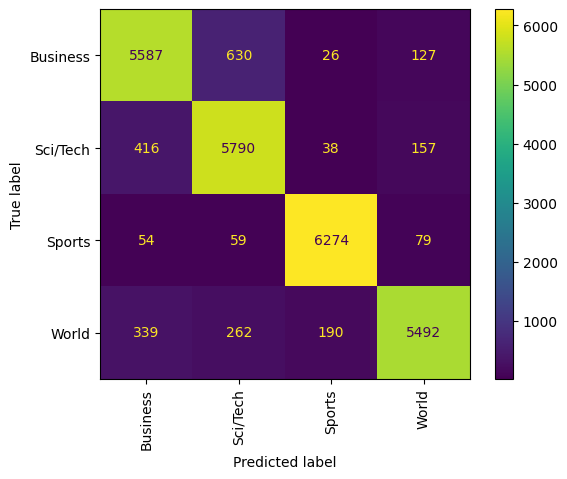

In [18]:
DSTorch.confusion_matrix(model_cnn, X_test, y_test, cn)

### Part 3: Precomputed Embeddings

14. We saw in the text the precomputed embeddings are faster and often more accurate for downstream models. Look at all of the available models from gensim:

In [19]:
import gensim.downloader as api

print(list(api.info()['models'].keys()))

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


15. We will load the `glove-wiki-gigaword-100` model here. It needs to download the first time, so it may take a few moments to finish.

In [20]:
pretrained = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


16. Find the closest words to banana, orange, and apple. Notice that these are not context specific, leading to some inconsistent results in the three fruit names.

In [35]:
pretrained.most_similar("banana", topn=10)

[('coconut', 0.7097253203392029),
 ('mango', 0.7054824829101562),
 ('bananas', 0.6887733340263367),
 ('potato', 0.6629636287689209),
 ('pineapple', 0.6534532308578491),
 ('fruit', 0.6519854664802551),
 ('peanut', 0.6420575976371765),
 ('pecan', 0.6349173188209534),
 ('cashew', 0.6294420957565308),
 ('papaya', 0.6246591210365295)]

In [22]:
pretrained.most_similar("orange", topn=10)

[('yellow', 0.7358633279800415),
 ('red', 0.7140780091285706),
 ('blue', 0.7118036150932312),
 ('green', 0.7111418843269348),
 ('pink', 0.677507221698761),
 ('purple', 0.6774231791496277),
 ('black', 0.6709616780281067),
 ('colored', 0.665260910987854),
 ('lemon', 0.6251963973045349),
 ('peach', 0.6168624758720398)]

In [23]:
pretrained.most_similar("apple", topn=10)

[('microsoft', 0.7449405193328857),
 ('ibm', 0.6821643114089966),
 ('intel', 0.6778088212013245),
 ('software', 0.6775422692298889),
 ('dell', 0.6741442680358887),
 ('pc', 0.6678153276443481),
 ('macintosh', 0.6617538332939148),
 ('iphone', 0.6595612168312073),
 ('ipod', 0.6534676551818848),
 ('hewlett', 0.6516579389572144)]

17. Try your own words as well and see what other terms the model places it next to.

In [36]:
pretrained.most_similar("train", topn=10)

[('trains', 0.8663254380226135),
 ('bus', 0.8473865389823914),
 ('rail', 0.7579620480537415),
 ('buses', 0.7380780577659607),
 ('passenger', 0.7333152890205383),
 ('commuter', 0.7288342118263245),
 ('subway', 0.7133814692497253),
 ('passengers', 0.7015968561172485),
 ('traffic', 0.6977760791778564),
 ('taxi', 0.6938237547874451)]

### Part 4: Refitting with Pretrained Embeddings

18. In this final section, we will embed the AG News data using the pretrained embeddings. Here is the code to match the words with the available vocabulary.

In [25]:
vocab = list(model.wv.key_to_index.keys())
embedding_dim = pretrained.vector_size

pretrained_matrix = np.zeros((len(vocab), embedding_dim))
found_count = 0

for i, word in enumerate(vocab):
    if word in pretrained:
        pretrained_matrix[i] = pretrained[word]
        found_count += 1
    else:
        pretrained_matrix[i] = np.random.uniform(-0.25, 0.25, embedding_dim)

print(f"Found {found_count} of {len(vocab)} words in pre-trained embeddings")
pretrained_matrix = torch.tensor(pretrained_matrix, dtype=torch.float32)

Found 11939 of 11993 words in pre-trained embeddings


19. And again, we can create a similar model.

In [26]:
model_pretrained = TextCNN(
    pretrained_matrix,
    num_classes=len(cn),
    num_filters=25,
    filter_size=3
)
optimizer_pretrained = optim.Adam(model_pretrained.parameters(), lr=0.0003)

20. And train it, using the saved weights if they are available.

In [27]:
try:
    model_pretrained.load_state_dict(torch.load("models/model_pre_agnews.pt"))
except FileNotFoundError:
    DSTorch.train(
        model_pretrained,
        optimizer_pretrained,
        X_train,
        y_train,
        num_epochs=10
    )
    torch.save(model_pretrained.state_dict(), "models/model_pre_agnews.pt")

21. Compare the error rates to the embeddings we trained ourselves:

In [28]:
DSTorch.score_text(model_pretrained, X_train, y_train)

0.928360104560852

In [29]:
DSTorch.score_text(model_pretrained, X_test, y_test)

0.9081896543502808

22. As well as the confusion matrix to the previous model.

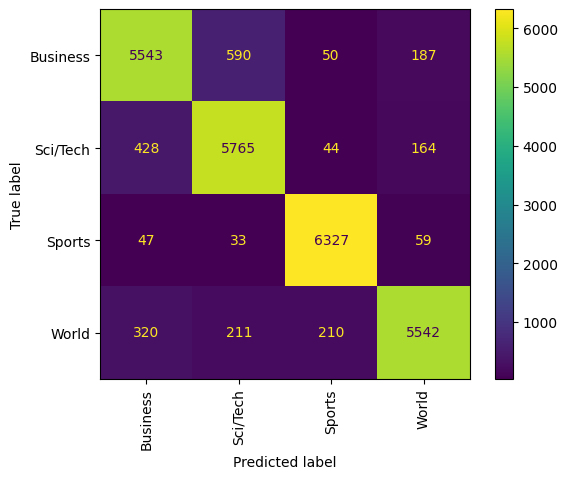

In [30]:
DSTorch.confusion_matrix(model_pretrained, X_test, y_test, cn)